In [12]:
from pathlib import Path
import sys, os

sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

import torch



from utils import scale_masses

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = np.load("../../Data/subboxes/train_subbox_halos.npy")
subbox_counts = np.load("../../Data/subboxes/train_subbox_counts.npy")

In [3]:
masses = []
for i in range(data.shape[0]):
    graph = data[i]
    count = subbox_counts[i]
    graph = torch.tensor(graph[:count, :])

    # total_cosmology_mass = torch.sum(graph[:, 6])
    masses.append(graph[:, 6])

individual_masses = torch.cat(masses)
log_masses = torch.log10(individual_masses)
print(f"Average mass: {torch.mean(log_masses)}, std: {torch.std(log_masses)}, min mass: {torch.min(log_masses)}, max mass: {torch.max(log_masses)}")    

Average mass: 14.627549171447754, std: 0.2728860378265381, min mass: 13.639039993286133, max mass: 16.180835723876953


(array([2.28000e+02, 4.93000e+02, 6.12000e+02, 6.83000e+02, 7.75000e+02,
        1.05200e+03, 1.95700e+03, 2.42100e+03, 3.67200e+03, 4.21600e+03,
        4.74700e+03, 6.64000e+03, 9.59100e+03, 1.19230e+04, 1.34660e+04,
        1.68890e+04, 2.10860e+04, 2.53020e+04, 2.82810e+04, 3.25220e+04,
        3.84460e+04, 4.48040e+04, 4.90610e+04, 5.44730e+04, 5.89670e+04,
        6.68450e+04, 7.31130e+04, 8.39120e+04, 9.56080e+04, 1.04471e+05,
        1.14508e+05, 1.22978e+05, 1.30256e+05, 1.39661e+05, 1.43987e+05,
        1.51041e+05, 1.53280e+05, 1.55326e+05, 1.60741e+05, 1.62277e+05,
        1.67925e+05, 1.65062e+05, 1.62898e+05, 1.58482e+05, 1.53065e+05,
        1.45093e+05, 1.35023e+05, 1.22442e+05, 1.09448e+05, 9.66280e+04,
        8.53000e+04, 7.40840e+04, 6.46130e+04, 5.65670e+04, 4.92860e+04,
        4.22480e+04, 3.63800e+04, 3.11630e+04, 2.66800e+04, 2.26930e+04,
        1.90890e+04, 1.61560e+04, 1.37450e+04, 1.14050e+04, 9.43600e+03,
        8.12000e+03, 6.49500e+03, 5.35100e+03, 4.29

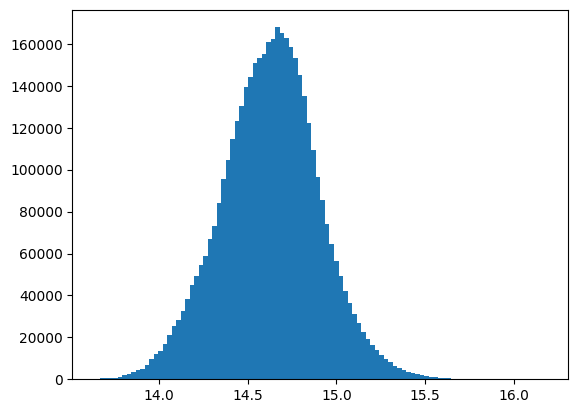

In [4]:
plt.hist(log_masses, bins=100)


tensor(0.9128) tensor(1.4384e-05)
Mean scaled log mass: 0.3550058901309967, std scaled log mass: 0.09799829125404358


(array([2.28000e+02, 4.93000e+02, 6.12000e+02, 6.83000e+02, 7.75000e+02,
        1.05200e+03, 1.95700e+03, 2.42100e+03, 3.67200e+03, 4.21600e+03,
        4.74700e+03, 6.64000e+03, 9.59100e+03, 1.19230e+04, 1.34660e+04,
        1.68890e+04, 2.10860e+04, 2.53020e+04, 2.82810e+04, 3.25220e+04,
        3.84460e+04, 4.48040e+04, 4.90790e+04, 5.44550e+04, 5.89690e+04,
        6.68430e+04, 7.31130e+04, 8.39120e+04, 9.56080e+04, 1.04471e+05,
        1.14509e+05, 1.22977e+05, 1.30256e+05, 1.39670e+05, 1.43979e+05,
        1.51040e+05, 1.53292e+05, 1.55317e+05, 1.60738e+05, 1.62284e+05,
        1.67920e+05, 1.65060e+05, 1.62908e+05, 1.58487e+05, 1.53050e+05,
        1.45093e+05, 1.35032e+05, 1.22433e+05, 1.09452e+05, 9.66240e+04,
        8.53000e+04, 7.40840e+04, 6.46140e+04, 5.65660e+04, 4.92860e+04,
        4.22480e+04, 3.63800e+04, 3.11650e+04, 2.66780e+04, 2.26930e+04,
        1.90890e+04, 1.61560e+04, 1.37450e+04, 1.14050e+04, 9.43600e+03,
        8.12000e+03, 6.49600e+03, 5.35000e+03, 4.29

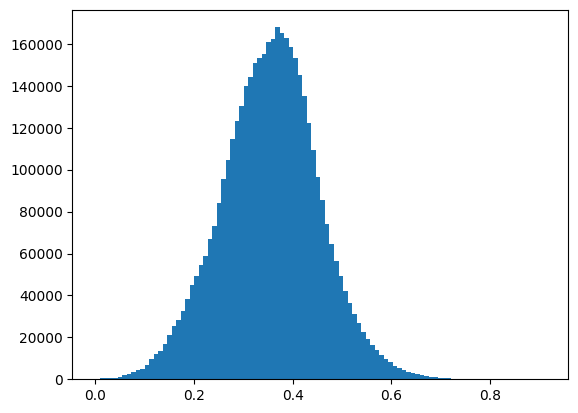

In [17]:
scaled_log_masses = scale_masses(log_masses)
print(torch.max(scaled_log_masses), torch.min(scaled_log_masses))
print(f"Mean scaled log mass: {torch.mean(scaled_log_masses)}, std scaled log mass: {torch.std(scaled_log_masses)}")

plt.hist(scaled_log_masses, bins=100)